In [ ]:
import os
os.environ["CODE_DIR"] = "SAM"

!git clone https://github.com/yuval-alaluf/SAM.git $CODE_DIR
os.chdir(f'./{os.environ["CODE_DIR"]}')

# Ninja build (needed for StyleGAN custom CUDA ops)
!wget https://github.com/ninja-build/ninja/releases/download/v1.8.2/ninja-linux.zip
!sudo unzip -o ninja-linux.zip -d /usr/local/bin/
!sudo update-alternatives --install /usr/bin/ninja ninja /usr/local/bin/ninja 1 --force

!pip install gdown ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

Cloning into 'SAM'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 228 (delta 32), reused 22 (delta 22), pack-reused 180 (from 1)
Receiving objects: 100% (228/228), 24.63 MiB | 21.74 MiB/s, done.
Resolving deltas: 100% (78/78), done.
--2026-07-03 06:12:00--  https://github.com/ninja-build/ninja/releases/download/v1.8.2/ninja-linux.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1335132/d2f252e2-9801-11e7-9fbf-bc7b4e4b5c83?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-03T07%3A08%3A11Z&rscd=attachment%3B+filename%3Dninja-linux.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-03T06%3A07%3A41Z&sk

In [ ]:
import gdown, os

os.makedirs("pretrained_models", exist_ok=True)
model_path = "pretrained_models/sam_ffhq_aging.pt"

# Assuming the file has been manually uploaded to 'pretrained_models/sam_ffhq_aging.pt'

print("Downloaded:", os.path.exists(model_path))

Downloaded: False


In [ ]:
from google.colab import files
uploaded = files.upload()
input_image_path = list(uploaded.keys())[0]
print("Uploaded:", input_image_path)

Saving mm1.jpg to mm1.jpg
Uploaded: mm1.jpg


In [ ]:
from google.colab import files

print("Please upload the 'shape_predictor_68_face_landmarks.dat' file.")
uploaded_predictor = files.upload()

# Verify the uploaded file
shape_predictor_path = "shape_predictor_68_face_landmarks.dat"
if shape_predictor_path in uploaded_predictor:
    print(f"Successfully uploaded: {shape_predictor_path}")
else:
    print(f"Warning: '{shape_predictor_path}' was not found among the uploaded files. Please ensure the filename matches exactly.")

Please upload the 'shape_predictor_68_face_landmarks.dat' file.


Saving mm1.jpg to mm1 (1).jpg


In [ ]:
import os
import bz2

print("Current directory:", os.getcwd())

# Download from dlib's official source (compressed)
!wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
print("bz2 downloaded:", os.path.exists("shape_predictor_68_face_landmarks.dat.bz2"))

# Decompress it
with bz2.BZ2File("shape_predictor_68_face_landmarks.dat.bz2") as f_in:
    data = f_in.read()
with open("shape_predictor_68_face_landmarks.dat", "wb") as f_out:
    f_out.write(data)

# Verify
size = os.path.getsize("shape_predictor_68_face_landmarks.dat")
print(f"Extracted, size: {size} bytes")  # should be ~99,693,937 bytes

Current directory: /content/SAM
bz2 downloaded: True
Extracted, size: 99693937 bytes


Aligned image has shape: (256, 256)


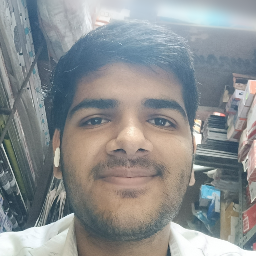

In [ ]:
import dlib

shape_predictor_path = "shape_predictor_68_face_landmarks.dat"

from scripts.align_all_parallel import align_face

def run_alignment(image_path):
    predictor = dlib.shape_predictor(shape_predictor_path)
    aligned_image = align_face(filepath=image_path, predictor=predictor)
    print("Aligned image has shape:", aligned_image.size)
    return aligned_image

aligned_image = run_alignment(input_image_path)
aligned_image.resize((256, 256))

In [ ]:
!wget -q https://github.com/italojs/facial-landmarks-recognition/raw/master/shape_predictor_68_face_landmarks.dat -O shape_predictor_68_face_landmarks.dat
print(os.path.getsize("shape_predictor_68_face_landmarks.dat"))

99693937


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
!nvidia-smi

CUDA available: True
CUDA version: 12.8
Fri Jul  3 06:12:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
!nvidia-smi

CUDA available: True
Fri Jul  3 06:12:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             28W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------

In [ ]:
import os
print("cwd:", os.getcwd())
print("pretrained_models exists:", os.path.exists("pretrained_models"))
if os.path.exists("pretrained_models"):
    print("contents:", os.listdir("pretrained_models"))

cwd: /content/SAM/SAM
pretrained_models exists: True
contents: []


In [ ]:
import os

# Go back to a known root
os.chdir("/content")
print("Reset to:", os.getcwd())

# See what's actually there
for root, dirs, files in os.walk("/content/SAM"):
    # skip going too deep into unrelated folders like .git
    if ".git" in root:
        continue
    depth = root.count(os.sep)
    if depth <= 4:
        print(root)

Reset to: /content
/content/SAM
/content/SAM/models
/content/SAM/models/__pycache__
/content/SAM/models/stylegan2
/content/SAM/models/encoders
/content/SAM/pretrained_models
/content/SAM/environment
/content/SAM/licenses
/content/SAM/configs
/content/SAM/configs/__pycache__
/content/SAM/scripts
/content/SAM/scripts/__pycache__
/content/SAM/docs
/content/SAM/training
/content/SAM/criteria
/content/SAM/criteria/lpips
/content/SAM/datasets
/content/SAM/SAM
/content/SAM/SAM/models
/content/SAM/SAM/pretrained_models
/content/SAM/SAM/environment
/content/SAM/SAM/licenses
/content/SAM/SAM/configs
/content/SAM/SAM/scripts
/content/SAM/SAM/docs
/content/SAM/SAM/training
/content/SAM/SAM/criteria
/content/SAM/SAM/datasets
/content/SAM/SAM/notebooks
/content/SAM/SAM/utils
/content/SAM/SAM/options
/content/SAM/notebooks
/content/SAM/notebooks/images
/content/SAM/utils
/content/SAM/options


In [ ]:
import os, shutil

os.chdir("/content")
if os.path.exists("SAM"):
    shutil.rmtree("SAM")
print("Cleaned. Now in:", os.getcwd())

Cleaned. Now in: /content


In [ ]:
os.environ["CODE_DIR"] = "SAM"
!git clone https://github.com/yuval-alaluf/SAM.git $CODE_DIR
os.chdir(f'./{os.environ["CODE_DIR"]}')
print("Now in:", os.getcwd())  # should print /content/SAM, not /content/SAM/SAM

Cloning into 'SAM'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 228 (delta 32), reused 22 (delta 22), pack-reused 180 (from 1)
Receiving objects: 100% (228/228), 24.63 MiB | 23.88 MiB/s, done.
Resolving deltas: 100% (78/78), done.
Now in: /content/SAM


In [ ]:
!wget https://github.com/ninja-build/ninja/releases/download/v1.8.2/ninja-linux.zip
!sudo unzip -o ninja-linux.zip -d /usr/local/bin/
!sudo update-alternatives --install /usr/bin/ninja ninja /usr/local/bin/ninja 1 --force

!pip install -q gdown ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

--2026-07-03 06:22:32--  https://github.com/ninja-build/ninja/releases/download/v1.8.2/ninja-linux.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1335132/d2f252e2-9801-11e7-9fbf-bc7b4e4b5c83?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-03T07%3A04%3A47Z&rscd=attachment%3B+filename%3Dninja-linux.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-03T06%3A04%3A28Z&ske=2026-07-03T07%3A04%3A47Z&sks=b&skv=2018-11-09&sig=uYuJgvzL4vTRyDe0s80OA3t8huN%2F%2BIbVzNSV5yyEz3I%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MzA2MDA1MiwibmJmIjoxNzgzMDU5NzUyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG

In [ ]:
import os

os.makedirs("pretrained_models", exist_ok=True)
model_path = "pretrained_models/sam_ffhq_aging.pt"

!wget -q --show-progress "https://huggingface.co/thang101020/aging/resolve/main/sam_ffhq_aging.pt" -O {model_path}

print("Downloaded:", os.path.exists(model_path))
if os.path.exists(model_path):
    print("Size:", os.path.getsize(model_path))  # expect ~2,270,000,000 bytes

pretrained_models/s 100%[===================>]   2.11G  4.25MB/s    in 3m 50s  
Downloaded: True
Size: 2270547237


In [ ]:
import torch
import sys
sys.path.append(".")
sys.path.append("..")

from models.psp import pSp
from argparse import Namespace

ckpt = torch.load(model_path, map_location='cpu')
opts = ckpt['opts']
opts['checkpoint_path'] = model_path
opts = Namespace(**opts)

net = pSp(opts)
net.eval()
net.cuda()
print("Model loaded successfully")

Loading SAM from checkpoint: pretrained_models/sam_ffhq_aging.pt
Model loaded successfully


In [ ]:
try:
    print("aligned_image exists, size:", aligned_image.size)
except NameError:
    print("aligned_image is missing — need to redo alignment")

import os
print("shape predictor still on disk:", os.path.exists("shape_predictor_68_face_landmarks.dat"))
print("input_image_path:", input_image_path if 'input_image_path' in dir() else "MISSING")

aligned_image exists, size: (256, 256)
shape predictor still on disk: False
input_image_path: mm1.jpg


Generated age 0
Generated age 10
Generated age 20
Generated age 30
Generated age 40
Generated age 50
Generated age 60
Generated age 70
Generated age 80
Generated age 90
Generated age 100


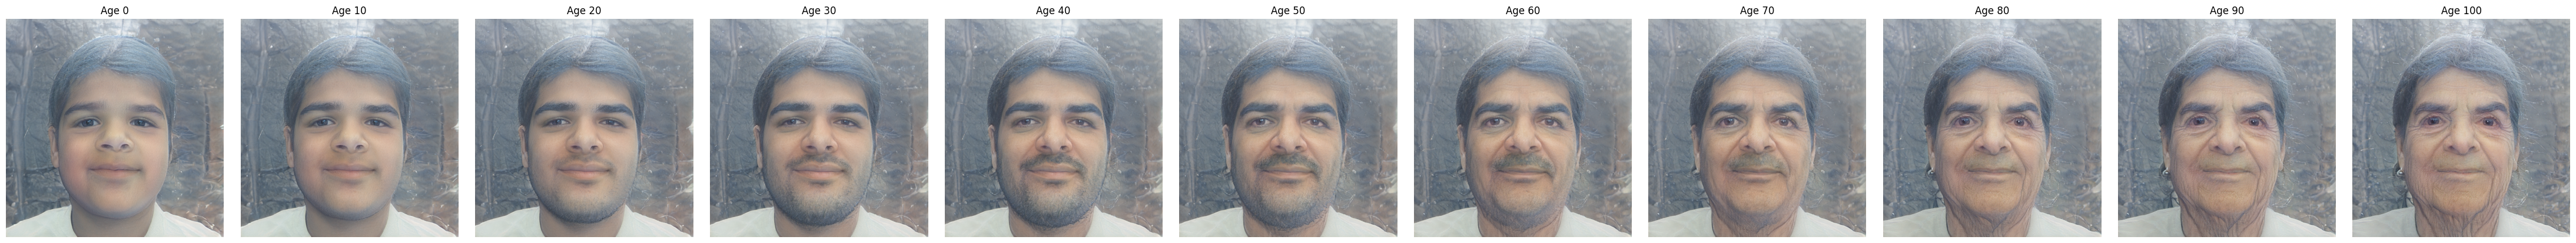

In [ ]:
import numpy as np
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

img_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

input_image = aligned_image.convert("RGB")
transformed_image = img_transforms(input_image)

def run_on_batch(inputs, net):
    with torch.no_grad():
        result_batch = net(inputs.to("cuda").float(), randomize_noise=False, resize=False)
    return result_batch

target_ages = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

results = []
for age in target_ages:
    age_transformer_input = transformed_image.clone()
    age_channel = torch.full((1, 256, 256), age / 100.0)
    input_with_age = torch.cat([age_transformer_input, age_channel], dim=0)
    result = run_on_batch(input_with_age.unsqueeze(0), net)
    result_image = result[0].cpu().detach()
    result_image = ((result_image + 1) / 2).clamp(0, 1)
    results.append(transforms.ToPILImage()(result_image))
    print(f"Generated age {age}")

fig, axes = plt.subplots(1, len(target_ages), figsize=(4*len(target_ages), 4))
for ax, img, age in zip(axes, results, target_ages):
    ax.imshow(img)
    ax.set_title(f"Age {age}")
    ax.axis("off")
plt.tight_layout()
plt.show()